## Final Project Submission

Please fill out:
* Student name: Tafford Pessah
* Student pace: part time
* Scheduled project review date/time: 
* Instructor name: Brian Chacha
* Blog post URL: 


### Business Problem

Your company is expanding in to new industries to diversify its portfolio. Specifically, they are interested in purchasing and operating airplanes for commercial and private enterprises, but do not know anything about the potential risks of aircraft. You are charged with determining which aircraft are the lowest risk for the company to start this new business endeavor. You must then translate your findings into actionable insights that the head of the new aviation division can use to help decide which aircraft to purchase.

### Key Points

* **Your analysis should yield three concrete business recommendations.** 
- Dealing with missing values
- Aggregating 
- Visualizing data

* **Communicating about your work well is extremely important.** 
- Create a storyline your audience (the head of the aviation division) can follow by walking them through the steps of your process, highlighting the most important points and skipping over the rest.

* **Use plenty of visualizations.** 
- Visualizations
- Simple visuals are usually best (e.g. bar charts and line graphs), and don't forget to format them well (e.g. labels, titles).

### 1.1 Reading the data in Panda Dataframe

In [1]:
# Your code here - remember to use markdown cells for comments as well!
import pandas as pd
import numpy as np
from numbers import Number
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Data\Aviation_Data.csv", index_col=0)

# Quick overview
print(df.shape)
print(df.columns)
df.head()

(90348, 30)
Index(['Investigation.Type', 'Accident.Number', 'Event.Date', 'Location',
       'Country', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category',
       'Registration.Number', 'Make', 'Model', 'Amateur.Built',
       'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Schedule',
       'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')


,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
Event.Id,,,,,,,,,,,,,,,,,,,,,
20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.9222,-81.8781,NaN,NaN,Fatal(3),...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


## Understanding the data structure

Here we want to understand the kind of dataframe in df we are handling by inspect the overall information in the dataframe:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90348 entries, 20001218X45444 to 20221230106513
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Investigation.Type      90348 non-null  object 
 1   Accident.Number         88889 non-null  object 
 2   Event.Date              88889 non-null  object 
 3   Location                88837 non-null  object 
 4   Country                 88663 non-null  object 
 5   Latitude                34382 non-null  object 
 6   Longitude               34373 non-null  object 
 7   Airport.Code            50249 non-null  object 
 8   Airport.Name            52790 non-null  object 
 9   Injury.Severity         87889 non-null  object 
 10  Aircraft.damage         85695 non-null  object 
 11  Aircraft.Category       32287 non-null  object 
 12  Registration.Number     87572 non-null  object 
 13  Make                    88826 non-null  object 
 14  Model                

In [4]:
df.describe(include='all')

,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
count,90348,88889,88889,88837,88663,34382,34373,50249,52790,87889,...,82697,16648,77488.000000,76379.000000,76956.000000,82977.000000,84397,61724,82508,73659
unique,71,88863,14782,27758,219,25592,27156,10375,24871,109,...,26,13590,NaN,NaN,NaN,NaN,4,12,17007,2923
top,Accident,ERA22FA338,1982-05-16,"ANCHORAGE, AK",United States,332739N,0112457W,NONE,Private,Non-Fatal,...,Personal,Pilot,NaN,NaN,NaN,NaN,VMC,Landing,Probable Cause,25-09-2020
freq,85015,2,25,434,82248,19,24,1488,240,67357,...,49448,258,NaN,NaN,NaN,NaN,77303,15428,61754,16317
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.647855,0.279881,0.357061,5.325440,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.485960,1.544084,2.235625,27.913634,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,2.000000,NaN,NaN,NaN,NaN


## Data Cleaning

### 1.1 Drop irrelevant or empty rows


Since the our data frame contains quite a number of missing values, We can also delete the entire rows for the columns with a small percentage of missing values.

In [5]:
# Deleting the rows associated with the columns with less than 5% of missing data
df = df.dropna(subset=['Location', 'Make', 'Model', 'Amateur.Built', 'Total.Fatal.Injuries', 'Country',
       'Injury.Severity', 'Aircraft.damage'], 
          how='any')

In [6]:
df.columns

Index(['Investigation.Type', 'Accident.Number', 'Event.Date', 'Location',
       'Country', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category',
       'Registration.Number', 'Make', 'Model', 'Amateur.Built',
       'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Schedule',
       'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')


Some columns such as 'Event.Id', 'Registration.Number', 'Report.Status' and 'Publication.Date' are not essential for our analysis, we'll delete them in order to remain with only essential columns and Drop columns that have a significant amount of missing data if they are not essential as well.

In [7]:
#lets drop columns with alot of missing entries and are not necessarily needed
df.drop(columns=[
    'Latitude', 'Longitude', 'FAR.Description', 'Schedule', 'Airport.Name', 'Report.Status',
    'Registration.Number', 'Air.carrier', 'Airport.Code', 'Publication.Date'
], inplace=True)


Lets also drop duplicates to further clean the data

In [8]:
#remove duplicates
df.drop_duplicates()
df.shape

(73951, 20)

### 1.2 Handle missing values

We'll start off by filling missing values with Unknown thus replacing Nan with 'Unknown'    

In [9]:
# Fill missing weather with 'Unknown'
df['Weather.Condition'] = df['Weather.Condition'].fillna('Unknown')

# filling the missing values with 'unknown' for the non numeric columns
df[['Purpose.of.flight', 'Engine.Type', 'Broad.phase.of.flight', 'Aircraft.Category']] = df[
    ['Purpose.of.flight', 'Engine.Type', 'Broad.phase.of.flight', 'Aircraft.Category']].fillna('unknown')

# Fill missing severity with 'Unknown'
df['Injury.Severity'] = df['Injury.Severity'].fillna('Unknown')

#deleting all rows where Aircraft.Category is not Airplanes or NaN's
df = df[(df['Aircraft.Category'] == 'Airplane') | (df['Aircraft.Category'].isna())]


We'll also replace numerical missing values with 0

In [10]:
# filling the numeric columns where there are missing values with 0
df[['Total.Uninjured', 'Total.Minor.Injuries', 'Total.Serious.Injuries', 'Number.of.Engines','Total.Fatal.Injuries']] = df[
    ['Total.Uninjured', 'Total.Minor.Injuries', 'Total.Serious.Injuries', 'Number.of.Engines','Total.Fatal.Injuries']].fillna(0.0)

In [11]:
df.isna().sum().sum()

0

There are no more Nan values in our data

Lets standardize our dates to have them in years for easy data analysis

In [12]:
#Convert date to year
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
df['Year'] = df['Event.Date'].dt.year
df['Year']


Event.Id
20020909X01562    1982
20020909X01561    1982
20020917X02148    1982
20020917X02134    1982
20020917X02119    1982
                  ... 
20221213106455    2022
20221215106463    2022
20221219106475    2022
20221219106470    2022
20221227106497    2022
Name: Year, Length: 22815, dtype: int64

We can standardize the values in 'Make' to avoid repetition as some values could be lowercased

In [13]:
#lets normalize Aircraft names to avoid duplicates
#.str.replace('-', ' ') removes hyphen inconsistencies - .str.strip() trims whitespace
df['Make'] = df['Make'].str.upper().str.replace('-', ' ').str.strip()
df['Make']

Event.Id
20020909X01562                        CESSNA
20020909X01561                        CESSNA
20020917X02148                      BELLANCA
20020917X02134                        CESSNA
20020917X02119                        NAVION
                             ...            
20221213106455                         PIPER
20221215106463            CIRRUS DESIGN CORP
20221219106475                    SWEARINGEN
20221219106470                        CESSNA
20221227106497    AMERICAN CHAMPION AIRCRAFT
Name: Make, Length: 22815, dtype: object

### Data Analysis

We can look at the statistical computations of our numerical columns data by using the .describe() function

In [14]:
df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Year
count,22815.000000,22815.000000,22815.000000,22815.000000,22815.000000,22815.000000
mean,1.047951,0.696384,0.284681,0.194302,3.641858,2009.998817
std,0.469997,6.149035,2.039928,0.907525,22.327492,11.932095
min,0.000000,0.000000,0.000000,0.000000,0.000000,1982.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2009.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000,2013.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000,2018.000000
max,8.000000,295.000000,161.000000,50.000000,576.000000,2022.000000


From the data above we can find the mean, standard deviation, the minimum & maximum values and the quatile values. okay, let's find the most common aircraft make that has experienced most accidents in our data.

In [15]:
df['Make'].mode()

0    CESSNA
dtype: object

In [16]:
df['Make'].value_counts().head(10)

CESSNA                7143
PIPER                 4121
BEECH                 1517
BOEING                 466
MOONEY                 357
BELLANCA               239
AIR TRACTOR INC        218
CIRRUS DESIGN CORP     217
GRUMMAN                214
AERONCA                197
Name: Make, dtype: int64

We can group our data to see the types of investigations we have:

In [17]:
#group by Investigation.Type and count occurrences
df1 = df.groupby('Investigation.Type').size()
df1

Investigation.Type
Accident    22263
Incident      552
dtype: int64

- Lets check Aircraft Damage vs Make

In [18]:
# Count how many times each make appears under each damage type
damage_make_counts = df.groupby(['Aircraft.damage', 'Make']).size().reset_index(name='Count')
damage_make_counts

,Aircraft.damage,Make,Count
0,Destroyed,3XTRIM,1
1,Destroyed,ACRODUSTER,1
2,Destroyed,AERMACCHI,1
3,Destroyed,AERO COMMANDER,21
4,Destroyed,AERO VODOCHODY,4
...,...,...,...
3520,Unknown,SWANN LYNN J,1
3521,Unknown,TEXTRON AVIATION,2
3522,Unknown,UNITED CONSULTANTS,1
3523,Unknown,VANS,1


We can filter, top 5 Aircraft Makes

In [19]:
# group by Investigation.Type and count occurrences WITHOUT overwriting the main dataframe `df`
investigation_counts = df.groupby('Investigation.Type').size()
investigation_counts

Investigation.Type
Accident    22263
Incident      552
dtype: int64

In [ ]:
df.columns.tolist()

['Investigation.Type',
 'Accident.Number',
 'Event.Date',
 'Location',
 'Country',
 'Injury.Severity',
 'Aircraft.damage',
 'Aircraft.Category',
 'Make',
 'Model',
 'Amateur.Built',
 'Number.of.Engines',
 'Engine.Type',
 'Purpose.of.flight',
 'Total.Fatal.Injuries',
 'Total.Serious.Injuries',
 'Total.Minor.Injuries',
 'Total.Uninjured',
 'Weather.Condition',
 'Broad.phase.of.flight',
 'Year']

In [26]:
# Group by Investigation Type and Aircraft Damage
risk_df = df.groupby(['Investigation.Type', 'Aircraft.damage']).agg(
    Total_Accidents=('Accident.Number', 'count'),
    Total_Fatal_Injuries=('Total.Fatal.Injuries', 'sum'),
    Total_Serious_Injuries=('Total.Serious.Injuries', 'sum'),
    Total_Minor_Injuries=('Total.Minor.Injuries', 'sum'),
    Total_Uninjured=('Total.Uninjured', 'sum')
).reset_index()

risk_df

,Investigation.Type,Aircraft.damage,Total_Accidents,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured
0,Accident,Destroyed,3368,11483.0,1038.0,961.0,1904.0
1,Accident,Minor,154,176.0,46.0,71.0,6738.0
2,Accident,Substantial,18674,4183.0,5294.0,3344.0,46425.0
3,Accident,Unknown,67,46.0,15.0,20.0,72.0
4,Incident,Minor,529,0.0,102.0,37.0,26498.0
5,Incident,Substantial,13,0.0,0.0,0.0,1061.0
6,Incident,Unknown,10,0.0,0.0,0.0,391.0


### Data Visualization
We'll start off our data visualization by checking the Aircraft Damage vs Injured in a stacked chart

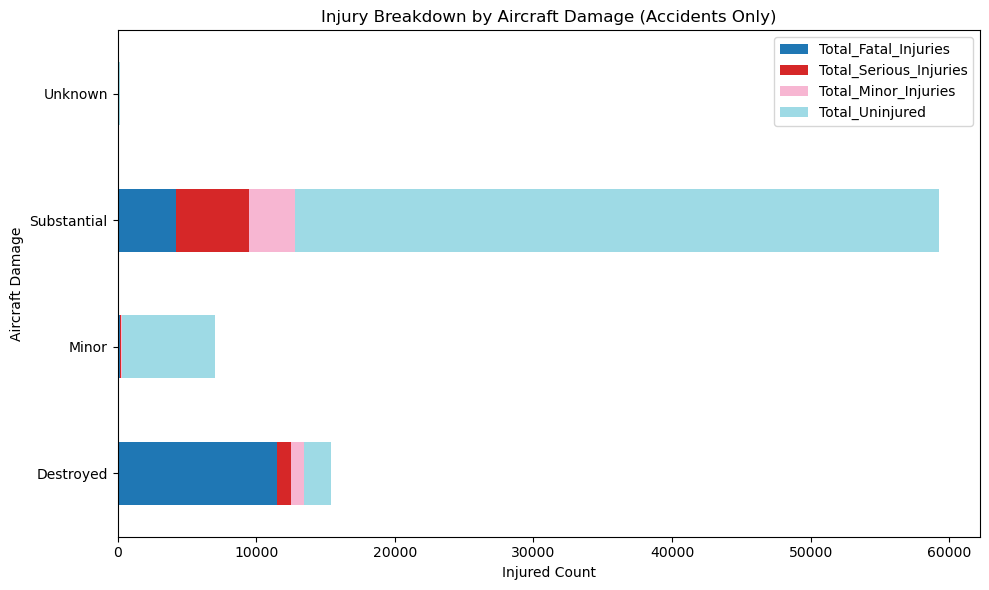

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for one investigation type (e.g., "Accident")
accident_df = risk_df.reset_index()
accident_df = accident_df[accident_df['Investigation.Type'] == 'Accident']

# Set index to Aircraft Damage
plot_df = accident_df.set_index('Aircraft.damage')[[
    'Total_Fatal_Injuries',
    'Total_Serious_Injuries',
    'Total_Minor_Injuries',
    'Total_Uninjured'
]]

# Plot horizontal stacked bar chart
plot_df.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='tab20')

plt.title('Injury Breakdown by Aircraft Damage (Accidents Only)')
plt.ylabel('Aircraft Damage')
plt.xlabel('Injured Count')
plt.tight_layout()
plt.show()


We can also check the top 5 most frequent aircrafts that have had damages, as below:

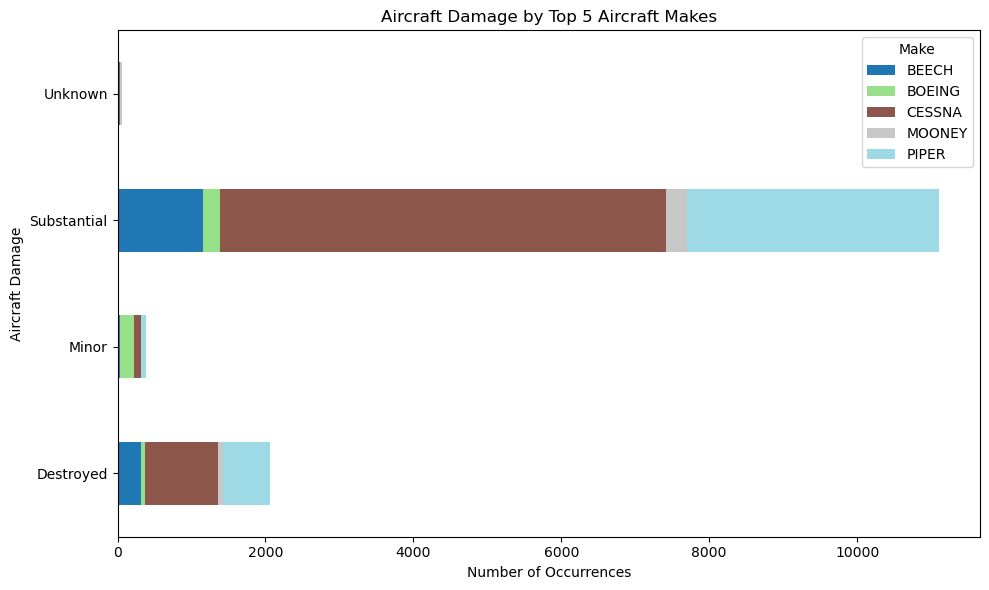

In [31]:
# Get top 5 most frequent aircraft makes
top_makes = df['Make'].value_counts().head(5).index

# Filter the grouped data
filtered = damage_make_counts[damage_make_counts['Make'].isin(top_makes)]

# Pivot to make Aircraft.damage the rows and Aircraft.Make the columns
pivot_df = filtered.pivot(index='Aircraft.damage', columns='Make', values='Count').fillna(0)

pivot_df.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Aircraft Damage by Top 5 Aircraft Makes')
plt.xlabel('Number of Occurrences')
plt.ylabel('Aircraft Damage')
plt.tight_layout()
plt.show()


### Risk based on the Make that have mostly encountered Accidents

Now, let's look at what Make of aircrafts have a record of the highest accident rate. We'll group by Make and count the Accident.Number occurances to see how many accidents a specific make has encountered.

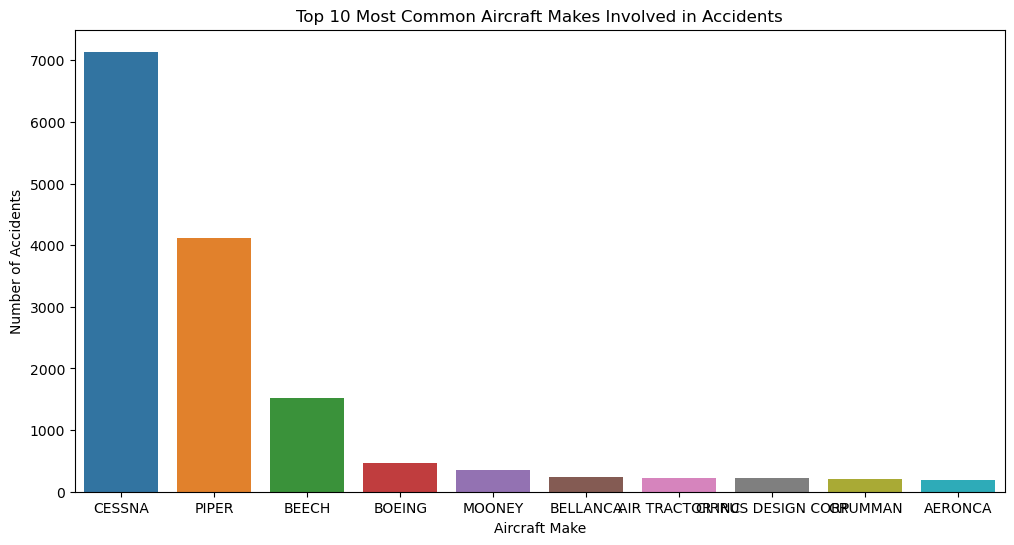

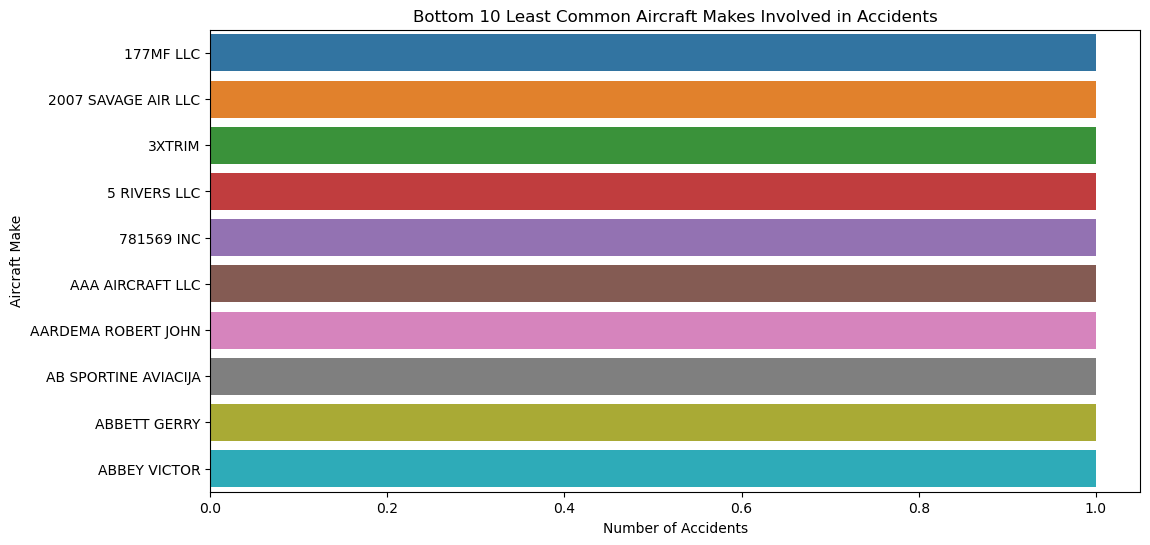

In [32]:
accident_counts = df.groupby('Make')['Accident.Number'].nunique().reset_index()

# Rename the column 
accident_counts.rename(columns={'Accident.Number': 'Accident.Count'}, inplace=True)

# Get the top 10 most common Makes
top_10_common = accident_counts.nlargest(10, 'Accident.Count')

# Get the bottom 10 least common Makes
bottom_10_common = accident_counts.nsmallest(10, 'Accident.Count')

# Plot the top 10 most common Makes
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_common, x='Make', y='Accident.Count')
plt.title('Top 10 Most Common Aircraft Makes Involved in Accidents')
plt.xlabel('Aircraft Make')
plt.ylabel('Number of Accidents');

# Plot the bottom 10 least common Makes
plt.figure(figsize=(12, 6))
sns.barplot(data=bottom_10_common, x='Accident.Count', y='Make')
plt.title('Bottom 10 Least Common Aircraft Makes Involved in Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Aircraft Make');

Finally, lets check for accidents over time and the top 5 makes with most accidents over time

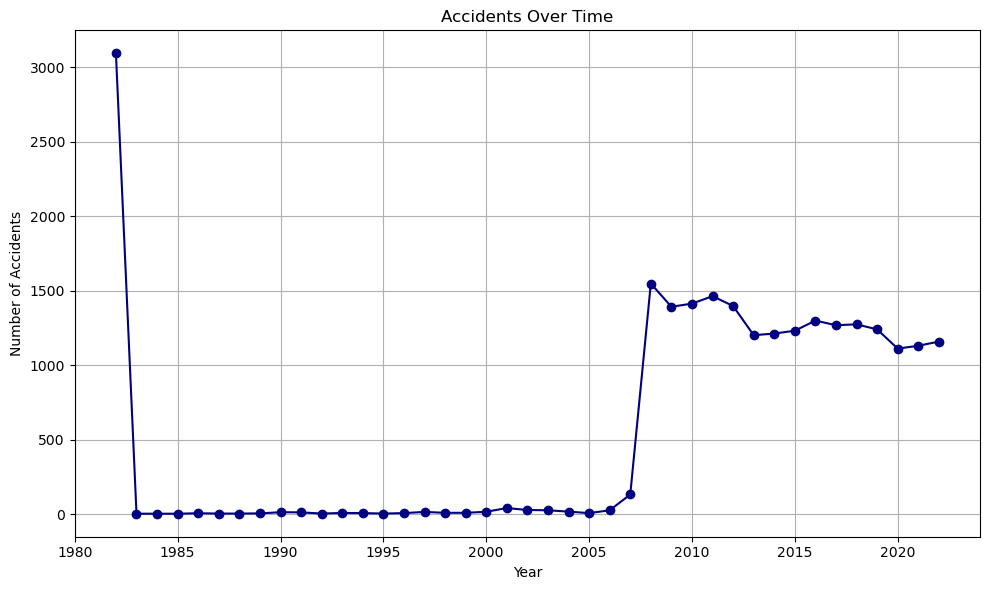

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by year
accidents_by_year = df.groupby('Year').size()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(accidents_by_year.index, accidents_by_year.values, marker='o', color='navy')
plt.title('Accidents Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.tight_layout()
plt.show()


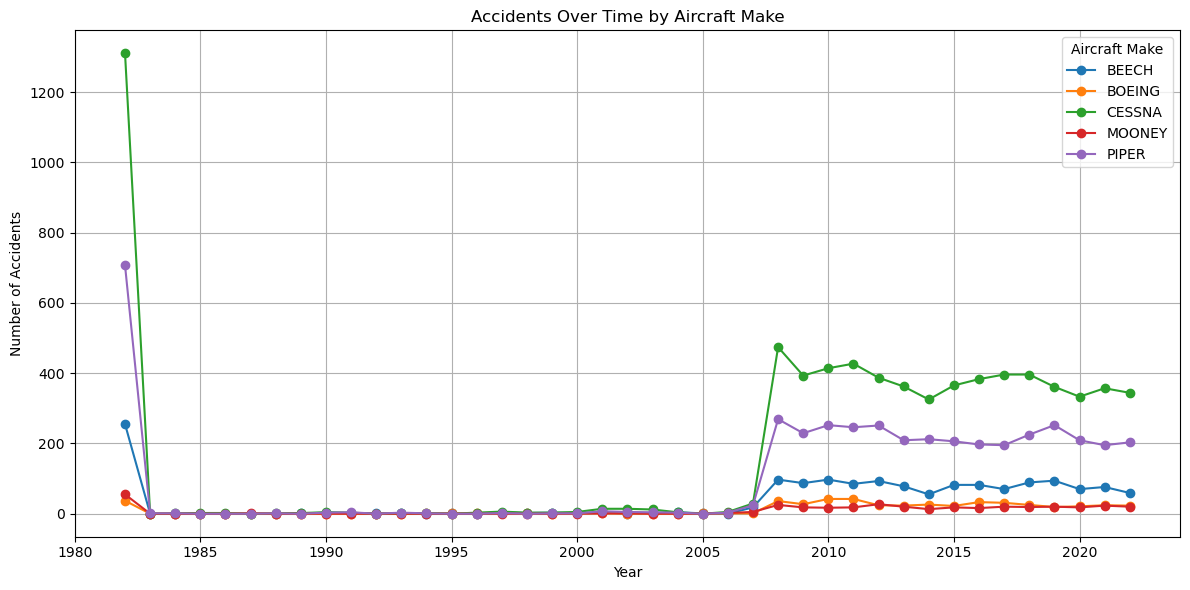

In [34]:

# Filter data
filtered_df = df[df['Make'].isin(top_makes)]

# Group by Year and Aircraft Make
grouped = filtered_df.groupby(['Year', 'Make']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
for make in grouped.columns:
    plt.plot(grouped.index, grouped[make], label=make, marker='o')

plt.title('Accidents Over Time by Aircraft Make')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend(title='Aircraft Make')
plt.grid(True)
plt.tight_layout()
plt.show()



- This shows which manufacturers have declining or rising accident trends

- This helps identify long-term safety performance


Now, we'll save the cleaned data frame df to a csv file named AviationData_clean.csv to use in further visualizations in Tableau

In [ ]:
#save the cleaned data to a csv file without including the index
df.to_csv('AviationData_clean.csv', index=False)

### Conclusion
In this analysis of aviation accident data from 1962 to 2023, we explored various risk factors that correlate with accident rates, focusing on identifying low-risk aircraft for potential investment. The findings can be summarized as follows:

We've been able to see that a large number of our aircraft Make and Model have recorded low accident rates and we have been able to identify what aircraft Make to avoid, the top two being Cessna and Piper while investing in aircrafts. We have also discovered that besides the Make of the Aircraft, that other factors such as Number of Engines and weather contribute to the risk of accidents occuring to aircrafts.

Based on these insights, it is recommended that the aviation division prioritize the acquisition of aircraft from categories with historically lower accident rates and develop strategies to mitigate risks associated with weather conditions.